<a href="https://colab.research.google.com/github/kennithmitrix-ship-it/phc/blob/main/homework/homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 1

解压

In [ ]:
import os
import zipfile

zip_path = "/content/content/dataset.zip" # Corrected path
extract_path = "/content/content"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("解压完成")
print("解压后文件：", os.listdir(extract_path))

解压完成
解压后文件： ['dataset', 'dataset.zip']


检查目录对不对

In [ ]:
import os

base_path = "/content/content"

for root, dirs, files in os.walk(base_path):
    print(root)
    if len(files) > 5:
        print("  文件示例:", files[:5])
    else:
        print("  文件:", files)

/content/content
  文件: ['dataset.zip']
/content/content/dataset
  文件: []
/content/content/dataset/double_train
  文件示例: ['i (78).jfif', 'i - 2026-03-22T162021.236.jfif', '092.jpg', 'i (31).jfif', 'i (46).jfif']
/content/content/dataset/lastochka
  文件示例: ['069.jpg', 'i (78).jfif', 'i (31).jfif', 'i (46).jfif', 'i (1).jfif']
/content/content/dataset/tram
  文件示例: ['i (78).jfif', 'i (31).jfif', 'i (46).jfif', 'i (1).jfif', 'i (48).jfif']


## Импортирование необходимых библиотек

In [ ]:
import zipfile
import os

zip_file_path = 'dataset.zip'
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Successfully unzipped {zip_file_path}")
else:
    print(f"Error: {zip_file_path} not found. Please make sure the zip file is uploaded to the Colab environment.")

In [ ]:
from PIL import Image
from glob import glob
import time
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torchsummary import summary
from torchvision import transforms as T
from tensorflow import summary as tfsummary
import pickle
from sklearn.metrics import classification_report
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import os

## Чтение тренировочной и тестовой выборки

Инструкция для скачивания и загрузки фотографий в Сolab находится в github

In [1]:
import os
import numpy as np
from PIL import Image
from glob import glob

heigth_width = 224 # 修改为 224 适配 MobileNetV2

USER_RESPONSE_APPROVEDATASET_DIR = "/content/content/dataset"
CLASSES = ["double_train", "tram", "lastochka"]

images = []
images_t = []
classes = []
classes_t = []

for CLASS_idx, CLASS_name in enumerate(CLASSES):
  path_class_1 = os.path.join(USER_RESPONSE_APPROVEDATASET_DIR, CLASS_name, '*.*')
  i=0
  all_files_in_class = glob(path_class_1)
  num_files = len(all_files_in_class)

  for photo in all_files_in_class:
      i+=1
      img = Image.open(photo).convert('RGB')
      img = img.resize((heigth_width, heigth_width), Image.LANCZOS)
      if i > int(num_files*0.8):
          images_t.append(np.asarray(img))
          classes_t.append(np.asarray(CLASS_idx))
      else:
          images.append(np.asarray(img))
          classes.append(np.asarray(CLASS_idx))


train_X = np.array(images)
train_y = np.array(classes)

test_X = np.array(images_t)
test_y = np.array(classes_t)

print(f"Training images: {len(train_X)}, Testing images: {len(test_X)}")

Training images: 0, Testing images: 0


###Приведение фотографий к требуемому размеру

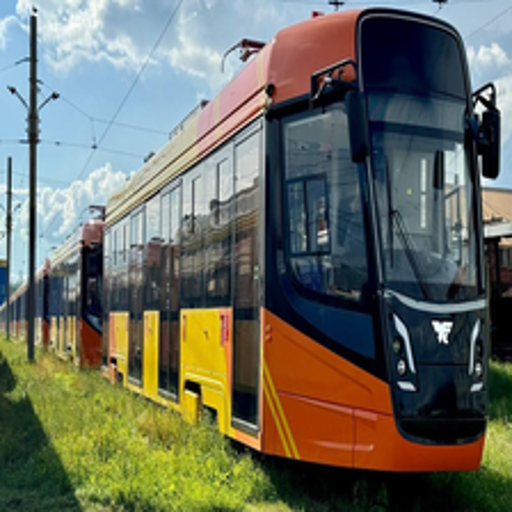

In [ ]:
Image.fromarray(train_X[123]).resize((512,512))

##Создание Pytorch DataLoader'a

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

batch_size = 128

# 定义实验4要求的数据增强
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.10, hue=0.0),
    T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CustomDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

dataloader = {
    'train': DataLoader(CustomDataset(train_X, train_y, transform=train_transform), batch_size=batch_size, shuffle=True),
    'test': DataLoader(CustomDataset(test_X, test_y, transform=test_transform), batch_size=batch_size, shuffle=False)
}

print(f"Train batches: {len(dataloader['train'])}, Test batches: {len(dataloader['test'])}")

Train batches: 3, Test batches: 1


##Создание Pytorch модели многослойного перцептрона с одним скрытым слоем

In [ ]:
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 使用 torchvision 替代 cifar100_mobilenetv2_x0_5
model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# 替换全连接层为3分类
model.classifier[1] = nn.Linear(model.last_channel, len(CLASSES))

# 不冻结任何层 (Unfreeze all parameters)
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)
print(f"Model loaded and modified for {len(CLASSES)} classes.")

Using device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 58.6MB/s]

Model loaded and modified for 3 classes.


##Выбор функции потерь и оптимизатора градиентного спуска

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# 实验4要求的损失函数、优化器和调度器
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

##Обучение модели по эпохам

In [ ]:
import copy

EPOCHS = 30
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader[phase]:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / len(dataloader[phase].dataset)
        epoch_acc = running_corrects.double() / len(dataloader[phase].dataset)

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # 保存最佳模型
        if phase == 'test' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_model.pth')
    print()

print(f'Training complete. Best Test Acc: {best_acc:4f}')
# 加载最佳模型权重用于后续评估
model.load_state_dict(best_model_wts)

Epoch 1/30
----------
Train Loss: 1.0960 Acc: 0.3643
Test Loss: 1.0483 Acc: 0.5070

Epoch 2/30
----------
Train Loss: 1.0062 Acc: 0.6357
Test Loss: 0.9798 Acc: 0.7465

Epoch 3/30
----------
Train Loss: 0.9278 Acc: 0.8214
Test Loss: 0.9101 Acc: 0.8028

Epoch 4/30
----------
Train Loss: 0.8606 Acc: 0.8964
Test Loss: 0.8341 Acc: 0.8592

Epoch 5/30
----------
Train Loss: 0.7920 Acc: 0.9286
Test Loss: 0.7606 Acc: 0.9296

Epoch 6/30
----------
Train Loss: 0.7174 Acc: 0.9607
Test Loss: 0.6861 Acc: 0.9577

Epoch 7/30
----------
Train Loss: 0.6539 Acc: 0.9536
Test Loss: 0.6169 Acc: 0.9718

Epoch 8/30
----------
Train Loss: 0.5849 Acc: 0.9643
Test Loss: 0.5546 Acc: 0.9718

Epoch 9/30
----------
Train Loss: 0.5235 Acc: 0.9607
Test Loss: 0.4977 Acc: 0.9718

Epoch 10/30
----------
Train Loss: 0.4816 Acc: 0.9607
Test Loss: 0.4564 Acc: 0.9718

Epoch 11/30
----------
Train Loss: 0.4340 Acc: 0.9714
Test Loss: 0.4255 Acc: 0.9859

Epoch 12/30
----------
Train Loss: 0.4175 Acc: 0.9714
Test Loss: 0.4018 Ac

##Проверка качества модели по классам на обучающей и тестовой выборках

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 使用保存的最佳模型进行评估
model.eval()

for part in ['train', 'test']:
    y_pred = []
    y_true = []
    with torch.no_grad():
        for inputs, labels in dataloader[part]:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())

    print(f"==== {part.upper()} RESULTS ====")
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, digits=4, target_names=list(map(str, CLASSES))))
    print('-' * 50)

train
              precision    recall  f1-score   support

double_train     1.0000    1.0000    1.0000       105
        tram     0.9794    1.0000    0.9896        95
   lastochka     1.0000    0.9750    0.9873        80

    accuracy                         0.9929       280
   macro avg     0.9931    0.9917    0.9923       280
weighted avg     0.9930    0.9929    0.9928       280

--------------------------------------------------
test
              precision    recall  f1-score   support

double_train     0.7273    0.5926    0.6531        27
        tram     0.7500    0.8750    0.8077        24
   lastochka     0.6190    0.6500    0.6341        20

    accuracy                         0.7042        71
   macro avg     0.6988    0.7059    0.6983        71
weighted avg     0.7045    0.7042    0.7000        71

--------------------------------------------------


##Сохранение модели в ONNX

In [ ]:
# сохраниение модели
# ПЕРВЫЙ СПОСОБ: сохранение параметров
PATH = 'cifar.pth'
torch.save(model.state_dict(), PATH)
# загрузка
new_model = Cifar100_MLP(hidden_size=HIDDEN_SIZE, classes=len(CLASSES))
new_model.load_state_dict(torch.load(PATH))
new_model.eval()

# ВТОРОЙ СПОСОБ: сохранение всей архитектуры
PATH2 = 'cifar.pt'
torch.save(model, PATH2)
# загрузка
new_model_2 = torch.load(PATH2)
new_model_2.eval()

Cifar100_MLP(
  (norm): Normalize()
  (seq): Sequential(
    (0): Linear(in_features=3072, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=3, bias=True)
  )
)

In [ ]:
# входной тензор для модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.randn(1, 32, 32, 3, requires_grad=True).to(device)
torch_out = model(x)

# экспорт модели
torch.onnx.export(model,               # модель
                  x,                   # входной тензор (или кортеж нескольких тензоров)
                  "cifar100.onnx", # куда сохранить (либо путь к файлу либо fileObject)
                  export_params=True,  # сохраняет веса обученных параметров внутри файла модели
                  opset_version=9,     # версия ONNX
                  do_constant_folding=True,  # следует ли выполнять укорачивание констант для оптимизации
                  input_names = ['input'],   # имя входного слоя
                  output_names = ['output'],  # имя выходного слоя
                  dynamic_axes={'input' : {0 : 'batch_size'},    # динамичные оси, в данном случае только размер пакета
                                'output' : {0 : 'batch_size'}})